In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchvision.models import efficientnet_b6, EfficientNet_B6_Weights
from torchvision.models import resnet50, ResNet50_Weights

import sys 
sys.path.append('/home/nfash/ICIS-Cancer-Detection/drew programs/')

from preprocessing import TumorPreprocessor
from discreterotation import DiscreteRotation
from ImageModel import ImageModel
import numpy as np
import random
import xgboost as xgb

from sklearn.metrics import roc_curve, auc
from scipy.integrate import trapezoid
from tqdm import tqdm

In [2]:
#set seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(p=0.5),
    DiscreteRotation(),
    transforms.RandomCrop(224, pad_if_needed=True),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])


Using device: cuda


In [3]:
def predict_proba(model, images):
        """Returns binary predictions (0 or 1) for given images."""
        model.model.eval()
        images = images.to(model.device)
    
        with torch.no_grad():
            outputs = model.model(images).squeeze()
            probas = torch.sigmoid(outputs)
    
        return probas.cpu()

In [4]:
current_dir = "/home/nfash/EECS_545/isic-2024-challenge/"

# Data loaders
csv_file = current_dir+"train-metadata.csv"
img_dir = current_dir+"train-image/image"
preprocessor = TumorPreprocessor(csv_file, 
                                 img_dir, 
                                 train_transform, 
                                 test_transform, 
                                 batch_size=64, 
                                 num_workers=15)


/home/nfash/ICIS-Cancer-Detection/drew programs/preprocessing.py:22: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(self.csv_file)


In [5]:
# Model setup
#ResNet50
OW = 10
LW = 1


train_loader, test_loader = preprocessor.get_dataloaders(OW=OW)
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# this is for resnet
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)
model.sigmoid = nn.Sigmoid() # Add sigmoid activation
model.to(device)

# Training components
malignant_weight = LW
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([malignant_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = GradScaler()

# Instantiate ImageModel
image_model = ImageModel(model, criterion, optimizer, scaler, 
                         device, test_loader, 
                         model_name="resnet50_OW_10_LW_1")
# Training
image_model.train(train_loader, epochs=1, verbose=True)

# Save model
save_path = current_dir + "tumor_classifier_resnet50_LW_%d_OW_%d.pth"%(LW,OW)
image_model.save_model(save_path)
print("Model saved successfully!")

# Evaluation
metrics = image_model.evaluate(verbose=True)

# Get probas
proba_arr = np.array([])
label_arr = np.array([])
for images, labels in tqdm(test_loader):
    probas = predict_proba(image_model, images)
    proba_arr = np.append(proba_arr,probas.numpy())
    label_arr = np.append(label_arr,labels)

# measure pAUC
fpr1, tpr1, thresholds = roc_curve(label_arr,proba_arr)

score = trapezoid(tpr1[tpr1>0.8]-0.8,fpr1[tpr1>0.8])
print(score)

/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/tmp/ipykernel_2353777/2357203272.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/nfash/ICIS-Cancer-Detection/drew programs/ImageModel.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/1], Step [50/5014], Loss: 0.4262
Epoch [1/1], Step [100/5014], Loss: 0.1637
Epoch [1/1], Step [150/5014], Loss: 0.1109
Epoch [1/1], Step [200/5014], Loss: 0.0852
Epoch [1/1], Step [250/5014], Loss: 0.0702
Epoch [1/1], Step [300/5014], Loss: 0.0257
Epoch [1/1], Step [350/5014], Loss: 0.0234
Epoch [1/1], Step [400/5014], Loss: 0.0244
Epoch [1/1], Step [450/5014], Loss: 0.0210
Epoch [1/1], Step [500/5014], Loss: 0.0591
Epoch [1/1], Step [550/5014], Loss: 0.1572
Epoch [1/1], Step [600/5014], Loss: 0.0224
Epoch [1/1], Step [650/5014], Loss: 0.0121
Epoch [1/1], Step [700/5014], Loss: 0.0165
Epoch [1/1], Step [750/5014], Loss: 0.0124
Epoch [1/1], Step [800/5014], Loss: 0.0141
Epoch [1/1], Step [850/5014], Loss: 0.0534
Epoch [1/1], Step [900/5014], Loss: 0.0124
Epoch [1/1], Step [950/5014], Loss: 0.0112
Epoch [1/1], Step [1000/5014], Loss: 0.0197
Epoch [1/1], Step [1050/5014], Loss: 0.0507
Epoch [1/1], Step [1100/5014], Loss: 0.0167
Epoch [1/1], Step [1150/5014], Loss: 0.0114
Epoch [1

100%|██████████| 1254/1254 [01:16<00:00, 16.41it/s]

0.12265842214533526


In [6]:
fpr, tpr, thresholds = roc_curve(label_arr,proba_arr)

score = trapezoid(tpr[tpr>0.8]-0.8,fpr[tpr>0.8])
print(score)

0.12265842214533526


In [7]:
# Model setup
#ResNet50
OW = 1000
LW = 1

train_loader, test_loader = preprocessor.get_dataloaders(OW=OW)
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# this is for resnet
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)
model.sigmoid = nn.Sigmoid() # Add sigmoid activation
model.to(device)

# Training components
malignant_weight = LW
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([malignant_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = GradScaler()

# Instantiate ImageModel
image_model = ImageModel(model, criterion, optimizer, scaler, 
                         device, test_loader, 
                         model_name="resnet50_OW_1000_LW_1")
# Training
image_model.train(train_loader, epochs=1, verbose=True)

# Save model
save_path = current_dir + "tumor_classifier_resnet50_LW_%d_OW_%d.pth"%(LW,OW)
image_model.save_model(save_path)
print("Model saved successfully!")

# Evaluation
metrics = image_model.evaluate(verbose=True)

# Get probas
proba_arr = np.array([])
label_arr = np.array([])
for images, labels in tqdm(test_loader):
    probas = predict_proba(image_model, images)
    proba_arr = np.append(proba_arr,probas.numpy())
    label_arr = np.append(label_arr,labels)

# measure pAUC
fpr2, tpr2, thresholds = roc_curve(label_arr,proba_arr)

score = trapezoid(tpr2[tpr2>0.8]-0.8,fpr2[tpr2>0.8])
print(score)

/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/tmp/ipykernel_2353777/2434718426.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/nfash/ICIS-Cancer-Detection/drew programs/ImageModel.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/1], Step [50/5014], Loss: 0.5063
Epoch [1/1], Step [100/5014], Loss: 0.3972
Epoch [1/1], Step [150/5014], Loss: 0.3698
Epoch [1/1], Step [200/5014], Loss: 0.2767
Epoch [1/1], Step [250/5014], Loss: 0.2087
Epoch [1/1], Step [300/5014], Loss: 0.1908
Epoch [1/1], Step [350/5014], Loss: 0.2294
Epoch [1/1], Step [400/5014], Loss: 0.1386
Epoch [1/1], Step [450/5014], Loss: 0.1759
Epoch [1/1], Step [500/5014], Loss: 0.1633
Epoch [1/1], Step [550/5014], Loss: 0.2727
Epoch [1/1], Step [600/5014], Loss: 0.0943
Epoch [1/1], Step [650/5014], Loss: 0.1842
Epoch [1/1], Step [700/5014], Loss: 0.1999
Epoch [1/1], Step [750/5014], Loss: 0.1626
Epoch [1/1], Step [800/5014], Loss: 0.0910
Epoch [1/1], Step [850/5014], Loss: 0.1246
Epoch [1/1], Step [900/5014], Loss: 0.0733
Epoch [1/1], Step [950/5014], Loss: 0.0786
Epoch [1/1], Step [1000/5014], Loss: 0.0853
Epoch [1/1], Step [1050/5014], Loss: 0.2747
Epoch [1/1], Step [1100/5014], Loss: 0.0866
Epoch [1/1], Step [1150/5014], Loss: 0.0718
Epoch [1

100%|██████████| 1254/1254 [01:16<00:00, 16.37it/s]

0.08296539281924811


In [8]:
# Model setup
#efficientnetb3
OW = 100
LW = 1


train_loader, test_loader = preprocessor.get_dataloaders(OW=OW)
model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

#this is for efficientnet
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 1)
model = model.to(device)

# Training components
malignant_weight = LW
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([malignant_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = GradScaler()

# Instantiate ImageModel
image_model = ImageModel(model, criterion, optimizer, scaler, 
                         device, test_loader, 
                         model_name="effnetb3_OW_100_LW_1")
# Training
image_model.train(train_loader, epochs=1, verbose=True)

# Save model
save_path = current_dir + "tumor_classifier_effnetb3_LW_%d_OW_%d.pth"%(LW,OW)
image_model.save_model(save_path)
print("Model saved successfully!")

# Evaluation
metrics = image_model.evaluate(verbose=True)

# Get probas
proba_arr = np.array([])
label_arr = np.array([])
for images, labels in tqdm(test_loader):
    probas = predict_proba(image_model, images)
    proba_arr = np.append(proba_arr,probas.numpy())
    label_arr = np.append(label_arr,labels)

# measure pAUC
fpr3, tpr3, thresholds = roc_curve(label_arr,proba_arr)

score = trapezoid(tpr3[tpr3>0.8]-0.8,fpr3[tpr3>0.8])
print(score)

/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/tmp/ipykernel_2353777/1617705801.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/nfash/ICIS-Cancer-Detection/drew programs/ImageModel.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/1], Step [50/5014], Loss: 0.6053
Epoch [1/1], Step [100/5014], Loss: 0.5366
Epoch [1/1], Step [150/5014], Loss: 0.4713
Epoch [1/1], Step [200/5014], Loss: 0.4390
Epoch [1/1], Step [250/5014], Loss: 0.3913
Epoch [1/1], Step [300/5014], Loss: 0.4009
Epoch [1/1], Step [350/5014], Loss: 0.3443
Epoch [1/1], Step [400/5014], Loss: 0.2947
Epoch [1/1], Step [450/5014], Loss: 0.3495
Epoch [1/1], Step [500/5014], Loss: 0.2102
Epoch [1/1], Step [550/5014], Loss: 0.1744
Epoch [1/1], Step [600/5014], Loss: 0.2799
Epoch [1/1], Step [650/5014], Loss: 0.2304
Epoch [1/1], Step [700/5014], Loss: 0.2703
Epoch [1/1], Step [750/5014], Loss: 0.1877
Epoch [1/1], Step [800/5014], Loss: 0.2533
Epoch [1/1], Step [850/5014], Loss: 0.1713
Epoch [1/1], Step [900/5014], Loss: 0.1946
Epoch [1/1], Step [950/5014], Loss: 0.1904
Epoch [1/1], Step [1000/5014], Loss: 0.1628
Epoch [1/1], Step [1050/5014], Loss: 0.1730
Epoch [1/1], Step [1100/5014], Loss: 0.1728
Epoch [1/1], Step [1150/5014], Loss: 0.2961
Epoch [1

100%|██████████| 1254/1254 [01:05<00:00, 19.11it/s]

0.1282469792703807


In [9]:
# Model setup
#efficientnetb3
OW = 100
LW = 2


train_loader, test_loader = preprocessor.get_dataloaders(OW=OW)
model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

#this is for efficientnet
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 1)
model = model.to(device)

# Training components
malignant_weight = LW
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([malignant_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = GradScaler()

# Instantiate ImageModel
image_model = ImageModel(model, criterion, optimizer, scaler, 
                         device, test_loader, 
                         model_name="effnetb3_OW_100_LW_2")
# Training
image_model.train(train_loader, epochs=1, verbose=True)

# Save model
save_path = current_dir + "tumor_classifier_effnetb3_LW_%d_OW_%d.pth"%(LW,OW)
image_model.save_model(save_path)
print("Model saved successfully!")

# Evaluation
metrics = image_model.evaluate(verbose=True)

# Get probas
proba_arr = np.array([])
label_arr = np.array([])
for images, labels in tqdm(test_loader):
    probas = predict_proba(image_model, images)
    proba_arr = np.append(proba_arr,probas.numpy())
    label_arr = np.append(label_arr,labels)

# measure pAUC
fpr4, tpr4, thresholds = roc_curve(label_arr,proba_arr)

score = trapezoid(tpr4[tpr4>0.8]-0.8,fpr4[tpr4>0.8])
print(score)

/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/tmp/ipykernel_2353777/2006053249.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/nfash/ICIS-Cancer-Detection/drew programs/ImageModel.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/1], Step [50/5014], Loss: 0.6837
Epoch [1/1], Step [100/5014], Loss: 0.7395
Epoch [1/1], Step [150/5014], Loss: 0.5637
Epoch [1/1], Step [200/5014], Loss: 0.5570
Epoch [1/1], Step [250/5014], Loss: 0.5162
Epoch [1/1], Step [300/5014], Loss: 0.4941
Epoch [1/1], Step [350/5014], Loss: 0.4773
Epoch [1/1], Step [400/5014], Loss: 0.2988
Epoch [1/1], Step [450/5014], Loss: 0.4623
Epoch [1/1], Step [500/5014], Loss: 0.5355
Epoch [1/1], Step [550/5014], Loss: 0.3480
Epoch [1/1], Step [600/5014], Loss: 0.4814
Epoch [1/1], Step [650/5014], Loss: 0.3006
Epoch [1/1], Step [700/5014], Loss: 0.5856
Epoch [1/1], Step [750/5014], Loss: 0.3054
Epoch [1/1], Step [800/5014], Loss: 0.2246
Epoch [1/1], Step [850/5014], Loss: 0.4929
Epoch [1/1], Step [900/5014], Loss: 0.2972
Epoch [1/1], Step [950/5014], Loss: 0.3529
Epoch [1/1], Step [1000/5014], Loss: 0.3593
Epoch [1/1], Step [1050/5014], Loss: 0.2827
Epoch [1/1], Step [1100/5014], Loss: 0.1782
Epoch [1/1], Step [1150/5014], Loss: 0.2987
Epoch [1

100%|██████████| 1254/1254 [01:05<00:00, 19.12it/s]

0.12184439571743619


In [10]:

# Model setup
#efficientnetb3
OW = 100
LW = 10


train_loader, test_loader = preprocessor.get_dataloaders(OW=OW)
model = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)

#this is for efficientnet
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 1)
model = model.to(device)

# Training components
malignant_weight = LW
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([malignant_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = GradScaler()

# Instantiate ImageModel
image_model = ImageModel(model, criterion, optimizer, scaler, 
                         device, test_loader, 
                         model_name="effnetb3_OW_100_LW_10")
# Training
image_model.train(train_loader, epochs=1, verbose=True)

# Save model
save_path = current_dir + "tumor_classifier_effnetb3_LW_%d_OW_%d.pth"%(LW,OW)
image_model.save_model(save_path)
print("Model saved successfully!")

# Evaluation
metrics = image_model.evaluate(verbose=True)

# Get probas
proba_arr = np.array([])
label_arr = np.array([])
for images, labels in tqdm(test_loader):
    probas = predict_proba(image_model, images)
    proba_arr = np.append(proba_arr,probas.numpy())
    label_arr = np.append(label_arr,labels)

# measure pAUC
fpr5, tpr5, thresholds = roc_curve(label_arr,proba_arr)

score = trapezoid(tpr5[tpr5>0.8]-0.8,fpr5[tpr5>0.8])
print(score)
    

/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/tmp/ipykernel_2353777/76938049.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/nfash/ICIS-Cancer-Detection/drew programs/ImageModel.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/1], Step [50/5014], Loss: 1.3150
Epoch [1/1], Step [100/5014], Loss: 1.3317
Epoch [1/1], Step [150/5014], Loss: 1.0432
Epoch [1/1], Step [200/5014], Loss: 1.2447
Epoch [1/1], Step [250/5014], Loss: 1.3774
Epoch [1/1], Step [300/5014], Loss: 0.9782
Epoch [1/1], Step [350/5014], Loss: 1.3377
Epoch [1/1], Step [400/5014], Loss: 0.9157
Epoch [1/1], Step [450/5014], Loss: 1.2462
Epoch [1/1], Step [500/5014], Loss: 0.9630
Epoch [1/1], Step [550/5014], Loss: 0.9354
Epoch [1/1], Step [600/5014], Loss: 0.7230
Epoch [1/1], Step [650/5014], Loss: 0.6820
Epoch [1/1], Step [700/5014], Loss: 0.6853
Epoch [1/1], Step [750/5014], Loss: 0.6770
Epoch [1/1], Step [800/5014], Loss: 1.1342
Epoch [1/1], Step [850/5014], Loss: 0.6416
Epoch [1/1], Step [900/5014], Loss: 0.8409
Epoch [1/1], Step [950/5014], Loss: 0.7943
Epoch [1/1], Step [1000/5014], Loss: 0.5619
Epoch [1/1], Step [1050/5014], Loss: 0.8768
Epoch [1/1], Step [1100/5014], Loss: 0.7888
Epoch [1/1], Step [1150/5014], Loss: 0.6058
Epoch [1

100%|██████████| 1254/1254 [01:05<00:00, 19.06it/s]

0.11687679991507785


In [11]:



# Model setup
#efficientnetb3
OW = 100
LW = 5


train_loader, test_loader = preprocessor.get_dataloaders(OW=OW)
model = efficientnet_b6(weights=EfficientNet_B6_Weights.IMAGENET1K_V1)

#this is for efficientnet
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 1)
model = model.to(device)

# Training components
malignant_weight = LW
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([malignant_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = GradScaler()

# Instantiate ImageModel
image_model = ImageModel(model, criterion, optimizer, scaler, 
                         device, test_loader, 
                         model_name="effnetb6_OW_%d_LW_%d"%(OW,LW))
# Training
image_model.train(train_loader, epochs=1, verbose=True)

# Save model
save_path = current_dir + "tumor_classifier_effnetb3_LW_%d_OW_%d.pth"%(LW,OW)
image_model.save_model(save_path)
print("Model saved successfully!")

# Evaluation
metrics = image_model.evaluate(verbose=True)

# Get probas
proba_arr = np.array([])
label_arr = np.array([])
for images, labels in tqdm(test_loader):
    probas = predict_proba(image_model, images)
    proba_arr = np.append(proba_arr,probas.numpy())
    label_arr = np.append(label_arr,labels)

# measure pAUC
fpr6, tpr6, thresholds = roc_curve(label_arr,proba_arr)

score = trapezoid(tpr6[tpr6>0.8]-0.8,fpr6[tpr6>0.8])
print(score)
    

/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)


Downloading: "https://download.pytorch.org/models/efficientnet_b6_lukemelas-24a108a5.pth" to /home/nfash/.cache/torch/hub/checkpoints/efficientnet_b6_lukemelas-24a108a5.pth


100%|██████████| 165M/165M [00:01<00:00, 104MB/s]  
/tmp/ipykernel_2353777/634940399.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/nfash/ICIS-Cancer-Detection/drew programs/ImageModel.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [1/1], Step [50/5014], Loss: 0.9411
Epoch [1/1], Step [100/5014], Loss: 0.8048
Epoch [1/1], Step [150/5014], Loss: 0.8914
Epoch [1/1], Step [200/5014], Loss: 0.8833
Epoch [1/1], Step [250/5014], Loss: 0.9529
Epoch [1/1], Step [300/5014], Loss: 0.7672
Epoch [1/1], Step [350/5014], Loss: 0.9693
Epoch [1/1], Step [400/5014], Loss: 0.9847
Epoch [1/1], Step [450/5014], Loss: 0.7975
Epoch [1/1], Step [500/5014], Loss: 0.6716
Epoch [1/1], Step [550/5014], Loss: 0.9354
Epoch [1/1], Step [600/5014], Loss: 0.7787
Epoch [1/1], Step [650/5014], Loss: 0.6652
Epoch [1/1], Step [700/5014], Loss: 0.4323
Epoch [1/1], Step [750/5014], Loss: 0.4532
Epoch [1/1], Step [800/5014], Loss: 0.5272
Epoch [1/1], Step [850/5014], Loss: 0.5930
Epoch [1/1], Step [900/5014], Loss: 0.4484
Epoch [1/1], Step [950/5014], Loss: 0.3617
Epoch [1/1], Step [1000/5014], Loss: 0.3232
Epoch [1/1], Step [1050/5014], Loss: 0.7239
Epoch [1/1], Step [1100/5014], Loss: 0.5648
Epoch [1/1], Step [1150/5014], Loss: 0.5678
Epoch [1

100%|██████████| 1254/1254 [02:38<00:00,  7.90it/s]

0.11774282849699079


# Repeat resnet w/ no augmentation:

In [14]:
# Transforms
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Data loaders
csv_file = current_dir+"train-metadata.csv"
img_dir = current_dir+"train-image/image"
preprocessor = TumorPreprocessor(csv_file, 
                                 img_dir, 
                                 train_transform, 
                                 test_transform, 
                                 batch_size=64, 
                                 num_workers=15)

# Model setup
#ResNet50
OW = 10
LW = 1


train_loader, test_loader = preprocessor.get_dataloaders(OW=OW)
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)

# this is for resnet
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 1)
model.sigmoid = nn.Sigmoid() # Add sigmoid activation
model.to(device)

# Training components
malignant_weight = LW
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([malignant_weight]).to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scaler = GradScaler()

# Instantiate ImageModel
image_model = ImageModel(model, criterion, optimizer, scaler, 
                         device, test_loader, 
                         model_name="resnet50_OW_10_LW_1_no_aug")
# Training
image_model.train(train_loader, epochs=1, verbose=True)

# Save model
save_path = current_dir + "tumor_classifier_resnet50_LW_%d_OW_%d_no_aug.pth"%(LW,OW)
image_model.save_model(save_path)
print("Model saved successfully!")

# Evaluation
metrics = image_model.evaluate(verbose=True)

# Get probas
proba_arr = np.array([])
label_arr = np.array([])
for images, labels in tqdm(test_loader):
    probas = predict_proba(image_model, images)
    proba_arr = np.append(proba_arr,probas.numpy())
    label_arr = np.append(label_arr,labels)

# measure pAUC
fpr7, tpr7, thresholds = roc_curve(label_arr,proba_arr)

score = trapezoid(tpr7[tpr7>0.8]-0.8,fpr7[tpr7>0.8])
print(score)

/home/nfash/ICIS-Cancer-Detection/drew programs/preprocessing.py:22: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(self.csv_file)
/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/home/nfash/ICIS-Cancer-Detection/drew programs/tumor_dataset.py:11: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  self.metadata = pd.read_csv(csv_file)
/tmp/ipykernel_2353777/1615406792.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/home/nfash/ICIS-Cancer-Detection/drew programs/ImageModel.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', 

Epoch [1/1], Step [50/5014], Loss: 0.3263
Epoch [1/1], Step [100/5014], Loss: 0.2356
Epoch [1/1], Step [150/5014], Loss: 0.0555
Epoch [1/1], Step [200/5014], Loss: 0.0979
Epoch [1/1], Step [250/5014], Loss: 0.0542
Epoch [1/1], Step [300/5014], Loss: 0.0235
Epoch [1/1], Step [350/5014], Loss: 0.0518
Epoch [1/1], Step [400/5014], Loss: 0.0152
Epoch [1/1], Step [450/5014], Loss: 0.0542
Epoch [1/1], Step [500/5014], Loss: 0.0144
Epoch [1/1], Step [550/5014], Loss: 0.0151
Epoch [1/1], Step [600/5014], Loss: 0.0188
Epoch [1/1], Step [650/5014], Loss: 0.0520
Epoch [1/1], Step [700/5014], Loss: 0.0138
Epoch [1/1], Step [750/5014], Loss: 0.0163
Epoch [1/1], Step [800/5014], Loss: 0.0111
Epoch [1/1], Step [850/5014], Loss: 0.0484
Epoch [1/1], Step [900/5014], Loss: 0.0336
Epoch [1/1], Step [950/5014], Loss: 0.0090
Epoch [1/1], Step [1000/5014], Loss: 0.0214
Epoch [1/1], Step [1050/5014], Loss: 0.0366
Epoch [1/1], Step [1100/5014], Loss: 0.0938
Epoch [1/1], Step [1150/5014], Loss: 0.0514
Epoch [1

100%|██████████| 1254/1254 [01:16<00:00, 16.32it/s]

0.049600071526656526


# Make ROC curve plot

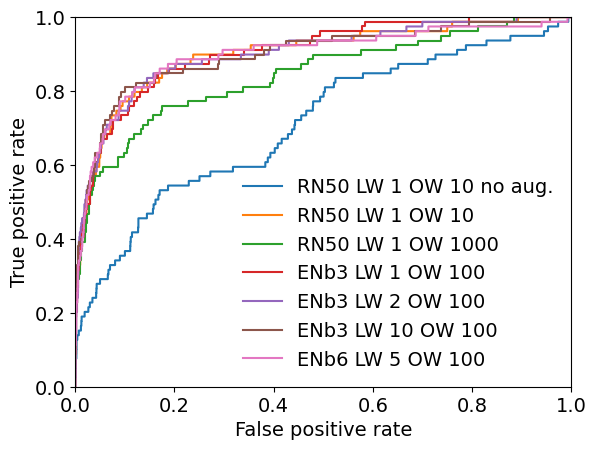

In [16]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.size']=14

plt.plot(fpr7,tpr7,label='RN50 LW %d OW %d no aug.'%(1,10))
plt.plot(fpr1,tpr1,label='RN50 LW %d OW %d'%(1,10))
plt.plot(fpr2,tpr2,label='RN50 LW %d OW %d'%(1,1000))

plt.plot(fpr3,tpr3,label='ENb3 LW %d OW %d'%(1,100))
plt.plot(fpr4,tpr4,label='ENb3 LW %d OW %d'%(2,100))
plt.plot(fpr5,tpr5,label='ENb3 LW %d OW %d'%(10,100))

plt.plot(fpr6,tpr6,label='ENb6 LW %d OW %d'%(5,100))


plt.legend(frameon=False)
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')

plt.xlim(0,1)
plt.ylim(0,1)

#plt.savefig('image_only_CNN_results.png',dpi=300,bbox_inches='tight')

In [12]:
# ### train_loader_for_embeddings = train_loader

# #xgboost stuff. NEEDS TO BE REFACTORED INTO NEW CLASS
# embedding_list = []
# label_list = []

# for images, labels in train_loader_for_embeddings:
#     embeddings = image_model.extract_embeddings(images)  # Embeddings on CPU
#     embedding_list.append(embeddings.numpy())
#     label_list.append(labels.numpy())

# X_train = np.vstack(embedding_list)
# y_train = np.concatenate(label_list)

# # Prepare data
# dtrain = xgb.DMatrix(X_train, label=y_train)
# # Calculate class weight for imbalance:
# num_negatives = np.sum(y_train == 0)
# num_positives = np.sum(y_train == 1)

In [13]:
# params = {
#     'objective': 'binary:logistic',
#     'eval_metric': 'logloss',
#     'tree_method': 'gpu_hist',  # GPU acceleration
#     'max_depth': 6,
#     'learning_rate': 0.01,
#     'scale_pos_weight': num_negatives / num_positives,
#     'subsample': 0.8,
#     'colsample_bytree': 0.8
# }

# bst = xgb.train(params, dtrain, num_boost_round=500)

# test_loader_for_embeddings = test_loader

# _, test_loader_for_embeddings = preprocessor.get_dataloaders()

# embedding_test_list = []
# label_test_list = []

# for images, labels in test_loader_for_embeddings:
#     embeddings = image_model.extract_embeddings(images)
#     embedding_test_list.append(embeddings.numpy())
#     label_test_list.append(labels.numpy())

# X_test = np.vstack(embedding_test_list)
# y_test = np.concatenate(label_test_list)

# dtest = xgb.DMatrix(X_test)
# y_pred_probs = bst.predict(dtest)
# y_pred = (y_pred_probs > 0.5).astype(int)

# from sklearn.metrics import classification_report
# print(classification_report(y_test, y_pred))
